## Example of using Decision Tree algorithm

Taken from https://scikit-learn.org/stable/auto_examples/tree/plot_iris_dtc.html

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

Plot the decision surface of a decision tree trained on pairs of features of the iris dataset.

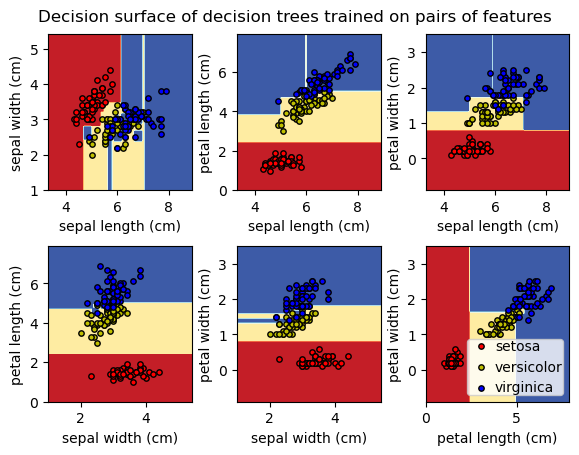

In [3]:


# Parameters
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02


for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # Train
    clf = DecisionTreeClassifier(criterion="entropy").fit(X, y)

    # Plot the decision boundary
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=iris.feature_names[pair[0]],
        ylabel=iris.feature_names[pair[1]],
    )

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=iris.target_names[i],
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

Display the structure of a single decision tree trained on all the features together.

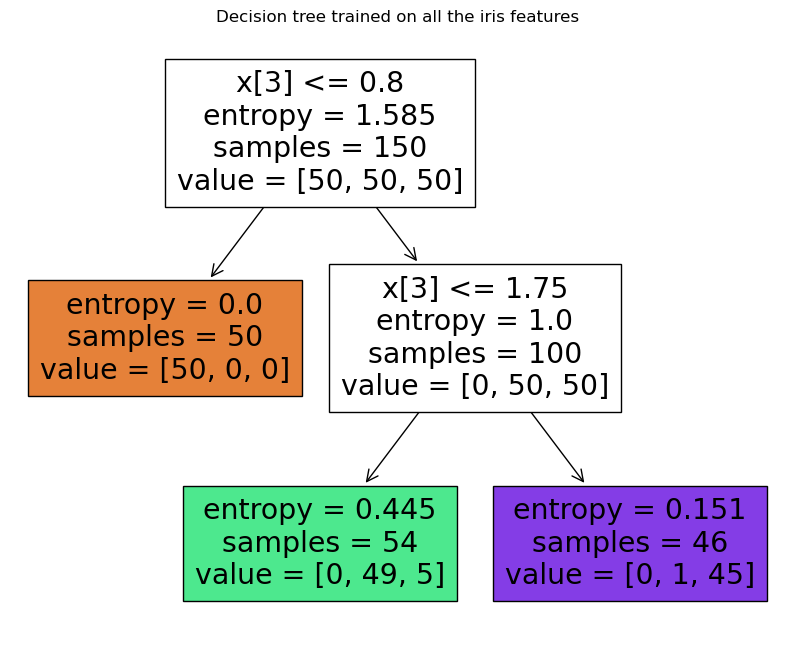

In [46]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 8))
# This produces exact tree with pure leafs which is likely to cause overfitting if applied to unlabeled data
#clf = DecisionTreeClassifier(criterion="entropy").fit(iris.data, iris.target)
# This will make a smaller but imprefect  tree
clf = DecisionTreeClassifier(max_leaf_nodes=3, criterion="entropy", random_state=0).fit(iris.data, iris.target)
plot_tree(clf, filled=True)
plt.title("Decision tree trained on all the iris features")
plt.show()

### Understanding tree structure 

Based on https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py

In [5]:
n_nodes = clf.tree_.node_count
children_left = clf.tree_.children_left
children_right = clf.tree_.children_right
feature = clf.tree_.feature
threshold = clf.tree_.threshold
values = clf.tree_.value

node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
is_leaves = np.zeros(shape=n_nodes, dtype=bool)
stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
while len(stack) > 0:
    # `pop` ensures each node is only visited once
    node_id, depth = stack.pop()
    node_depth[node_id] = depth

    # If the left and right child of a node is not the same we have a split
    # node
    is_split_node = children_left[node_id] != children_right[node_id]
    # If a split node, append left and right children and depth to `stack`
    # so we can loop through them
    if is_split_node:
        stack.append((children_left[node_id], depth + 1))
        stack.append((children_right[node_id], depth + 1))
    else:
        is_leaves[node_id] = True

print(
    "The binary tree structure has {n} nodes and has "
    "the following tree structure:\n".format(n=n_nodes)
)
for i in range(n_nodes):
    if is_leaves[i]:
        print(
            "{space}node={node} is a leaf node with value={value}.".format(
                space=node_depth[i] * "\t", node=i, value=np.around(values[i], 3)
            )
        )
    else:
        print(
            "{space}node={node} is a split node with value={value}: "
            "go to node {left} if X[:, {feature}] <= {threshold} "
            "else to node {right}.".format(
                space=node_depth[i] * "\t",
                node=i,
                left=children_left[i],
                feature=feature[i],
                threshold=threshold[i],
                right=children_right[i],
                value=np.around(values[i], 3),
            )
        )



The binary tree structure has 17 nodes and has the following tree structure:

node=0 is a split node with value=[[50. 50. 50.]]: go to node 1 if X[:, 3] <= 0.800000011920929 else to node 2.
	node=1 is a leaf node with value=[[50.  0.  0.]].
	node=2 is a split node with value=[[ 0. 50. 50.]]: go to node 3 if X[:, 3] <= 1.75 else to node 12.
		node=3 is a split node with value=[[ 0. 49.  5.]]: go to node 4 if X[:, 2] <= 4.950000047683716 else to node 7.
			node=4 is a split node with value=[[ 0. 47.  1.]]: go to node 5 if X[:, 3] <= 1.6500000357627869 else to node 6.
				node=5 is a leaf node with value=[[ 0. 47.  0.]].
				node=6 is a leaf node with value=[[0. 0. 1.]].
			node=7 is a split node with value=[[0. 2. 4.]]: go to node 8 if X[:, 3] <= 1.550000011920929 else to node 9.
				node=8 is a leaf node with value=[[0. 0. 3.]].
				node=9 is a split node with value=[[0. 2. 1.]]: go to node 10 if X[:, 0] <= 6.949999809265137 else to node 11.
					node=10 is a leaf node with value=[[0. 2

In [21]:
# Let's train again using all features

In [22]:
iris = load_iris()
X = iris.data
y = iris.target


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

clf2 = DecisionTreeClassifier(max_leaf_nodes=3, random_state=0)
clf2.fit(X_train, y_train)


DecisionTreeClassifier(max_leaf_nodes=3, random_state=0)

Retrieve the decision path of samples of interest. We will use sampel with index 0 below.

In [23]:
node_indicator = clf.decision_path(X_test)
leaf_id = clf.apply(X_test)

sample_id = 0
# obtain ids of the nodes `sample_id` goes through, i.e., row `sample_id`
node_index = node_indicator.indices[
    node_indicator.indptr[sample_id] : node_indicator.indptr[sample_id + 1]
]

print("Rules used to predict sample {id}:\n".format(id=sample_id))
for node_id in node_index:
    # continue to the next node if it is a leaf node
    if leaf_id[sample_id] == node_id:
        continue

    # check if value of the split feature for sample 0 is below threshold
    if X_test[sample_id, feature[node_id]] <= threshold[node_id]:
        threshold_sign = "<="
    else:
        threshold_sign = ">"

    print(
        "decision node {node} : (X_test[{sample}, {feature}] = {value}) "
        "{inequality} {threshold})".format(
            node=node_id,
            sample=sample_id,
            feature=feature[node_id],
            value=X_test[sample_id, feature[node_id]],
            inequality=threshold_sign,
            threshold=threshold[node_id],
        )
    )

Rules used to predict sample 0:

decision node 0 : (X_test[0, 3] = 2.4) > 0.800000011920929)
decision node 2 : (X_test[0, 3] = 2.4) > 1.75)
decision node 12 : (X_test[0, 2] = 5.1) > 4.8500001430511475)


For a group of samples, we can determine the common nodes the samples go through.

In [25]:

sample_ids = [0, 1, 2]
# boolean array indicating the nodes both samples go through
common_nodes = node_indicator.toarray()[sample_ids].sum(axis=0) == len(sample_ids)
# obtain node ids using position in array
common_node_id = np.arange(n_nodes)[common_nodes]

print(
    "\nThe following samples {samples} share the node(s) {nodes} in the tree.".format(
        samples=sample_ids, nodes=common_node_id
    )
)
print("This is {prop}% of all nodes.".format(prop=100 * len(common_node_id) / n_nodes))




The following samples [0, 1, 2] share the node(s) [0] in the tree.
This is 5.882352941176471% of all nodes.


## Using Random Forest and evaluating its performance

**Explanation**

    Learning Curve:

        Using RandomForestClassifier on the Breast Cancer dataset, the learning curve shows how the error rate on training and validation sets changes as the training set size increases.

        A gap between training and validation error may indicate whether more data could help improve performance.

    ROC Curve:

        After splitting data into training and test sets, the model’s performance is measured using the ROC curve.

        The area under the ROC curve (ROC AUC) gives a threshold-independent performance measure.

    Feature Selection Analysis:

        The classifier’s feature importances (computed as the average decrease in impurity) are used to rank features.

        For various numbers of top features (from 5 up to the total available), cross-validated accuracy and ROC AUC are computed to identify the optimal feature subset.

        This helps decide how many features to use, balancing model simplicity and performance.

        A bar chart of sorted feature importances is also plotted to visualize which features are most influential.

    Visualization:

        The plots (learning curve, ROC curve, and performance vs. number of features) together provide insight into both data sufficiency and the optimal feature subset size.

In [26]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import learning_curve, train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.feature_selection import SelectKBest  # (Not used here, but mentioned for context)




In [27]:
# -------------------------
# 1. Load the Breast Cancer Dataset
# -------------------------
# This classical dataset has 2 labels (binary classification problem)
# and 13 features 
#  see https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

data = load_breast_cancer()
X = data.data           # Feature matrix (n_samples, n_features)
y = data.target         # Binary labels
feature_names = data.feature_names



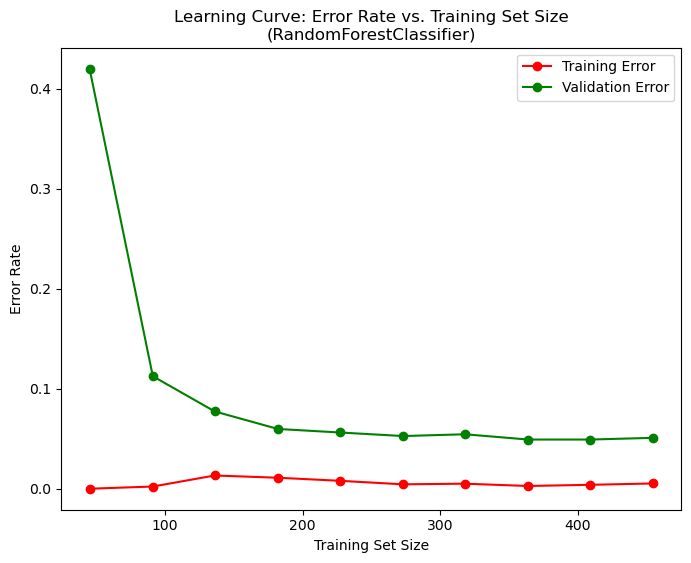

In [29]:
# -------------------------
# 2. Learning Curve: Error Rate vs. Training Set Size using RandomForest
# -------------------------

# StratifiedKFold provides train/test indices to split data in train/test sets.
#This cross-validation object is a variation of KFold that returns stratified folds.
#The folds are made by preserving the percentage of samples for each class.

#cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Define the model: RandomForest with 10 trees.
model = RandomForestClassifier(n_estimators=10, random_state=42)

# Compute learning curve using 'accuracy'; error rate = 1 - accuracy
train_sizes, train_scores, test_scores = learning_curve(model, X, y,
                                                        cv=5,
                                                        scoring='accuracy',
                                                        train_sizes=np.linspace(0.1, 1.0, 10),
                                                        random_state=42)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
train_error = 1 - train_mean
test_error = 1 - test_mean

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_error, 'o-', color="red", label="Training Error")
plt.plot(train_sizes, test_error, 'o-', color="green", label="Validation Error")
plt.xlabel("Training Set Size")
plt.ylabel("Error Rate")
plt.title("Learning Curve: Error Rate vs. Training Set Size\n(RandomForestClassifier)")
plt.legend(loc="best")
plt.show()



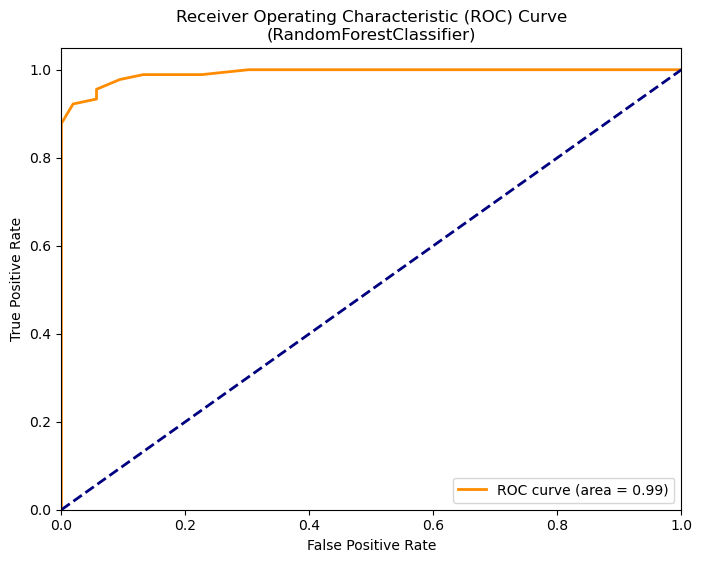

In [30]:
# -------------------------
# 3. ROC Curve: Evaluate Classifier Performance
# -------------------------
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
model.fit(X_train, y_train)
# For ROC curve, use predict_proba to obtain scores for the positive class
# predict_proba returns an array of predicted probabilities for each class, for each sample in the test set.
# binary classification problem, the output will have shape (n_samples,2)(n_samples,2) where the first column 
# corresponds to the probability for class 0 and the second column corresponds to the probability for class 1.

y_score = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve\n(RandomForestClassifier)")
plt.legend(loc="lower right")
plt.show()



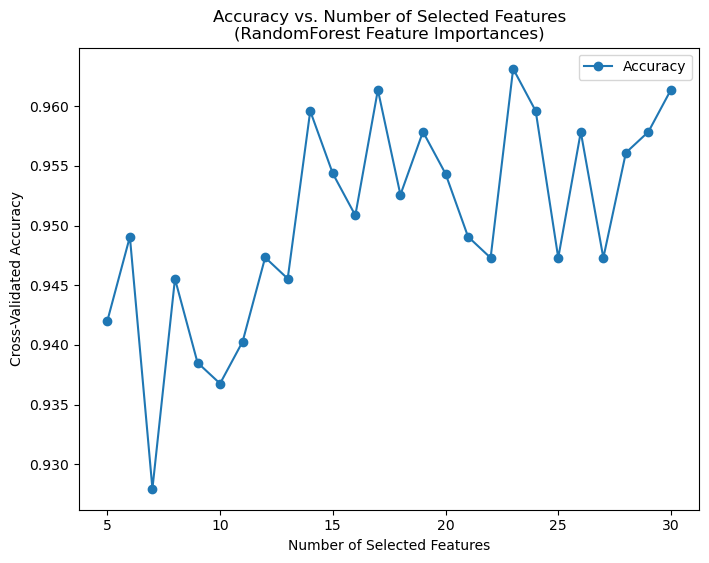

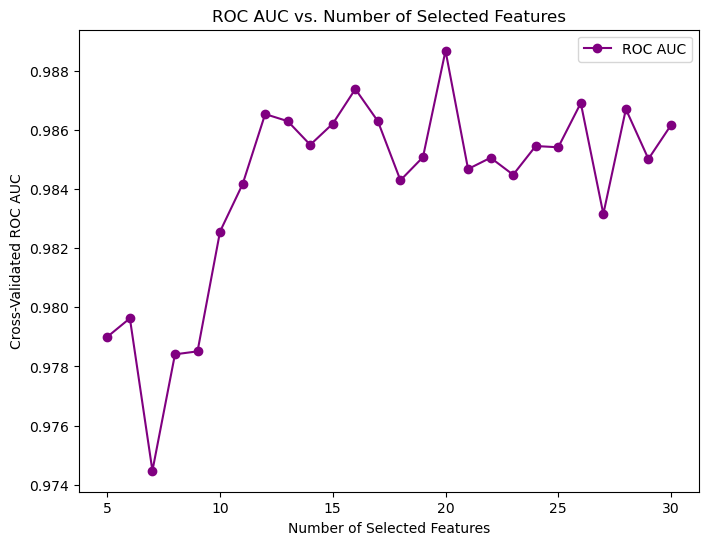

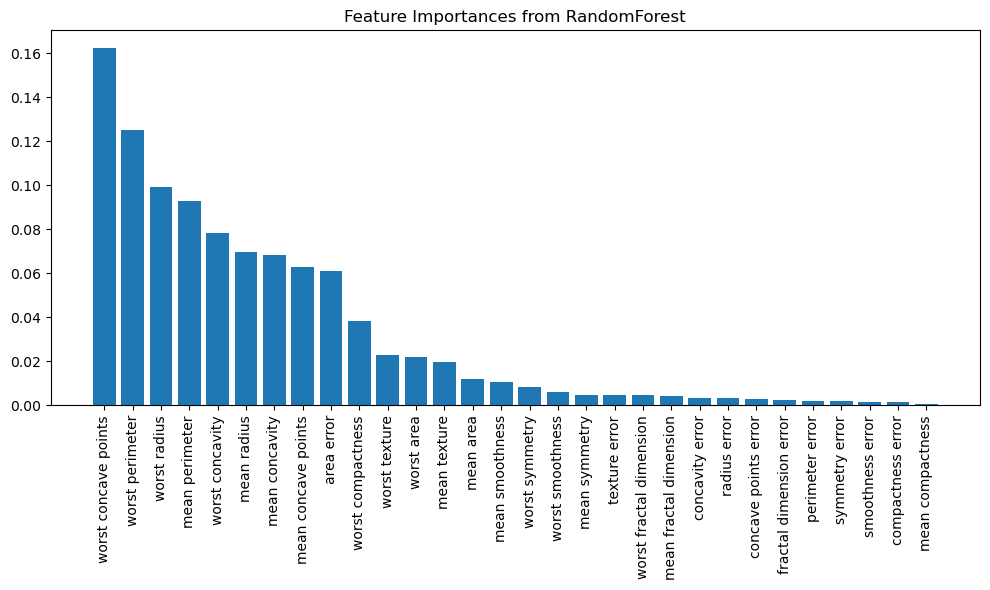

In [33]:
# -------------------------
# 4. Feature Selection Analysis using RandomForest Feature Importances
# -------------------------
# Fit a RandomForestClassifier on the full dataset to extract feature importances.
model.fit(X, y)
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]  # indices of features sorted by importance (descending order)

# Evaluate classifier performance using different numbers of top features
n_total_features = X.shape[1]
feature_counts = range(5, n_total_features + 1)  # from 5 features up to all features
accuracy_list = []
roc_auc_list = []

for k in feature_counts:
    # Select the top k features based on RandomForest feature_importances_
    topk_indices = indices[:k]
    X_topk = X[:, topk_indices]
    
    # Use cross validation to estimate performance
    cv_accuracy = cross_val_score(model, X_topk, y, cv=5, scoring='accuracy')
    accuracy_list.append(np.mean(cv_accuracy))
    
    cv_roc = cross_val_score(model, X_topk, y, cv=5, scoring='roc_auc')
    roc_auc_list.append(np.mean(cv_roc))

# Plot cross-validated accuracy vs. number of selected features
# The features are first ranked by their importance using the RandomForest’s feature_importances_ attribute.
# The features are then selected in descending order of importance (i.e., the most important features come first).

plt.figure(figsize=(8,6))
plt.plot(list(feature_counts), accuracy_list, 'o-', label="Accuracy")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Accuracy vs. Number of Selected Features\n(RandomForest Feature Importances)")
plt.legend(loc="best")
plt.show()

# Plot cross-validated ROC AUC vs. number of selected features
plt.figure(figsize=(8,6))
plt.plot(list(feature_counts), roc_auc_list, 'o-', color="purple", label="ROC AUC")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated ROC AUC")
plt.title("ROC AUC vs. Number of Selected Features")
plt.legend(loc="best")
plt.show()

# Plot feature importances as a bar chart for interpretation
plt.figure(figsize=(10,6))
plt.title("Feature Importances from RandomForest")
plt.bar(range(n_total_features), importances[indices], align="center")
plt.xticks(range(n_total_features), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()